# 00 — LOBSTER data audit

Run this notebook only after `scripts/download_lobster.ps1`.

In [3]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

# Handle both Jupyter Lab and VS Code notebook working directories.
current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

source_directory = project_root / "src"
data_root = project_root / "data" / "raw" / "lobster"

if str(source_directory) not in sys.path:
    sys.path.insert(0, str(source_directory))

from orderbook_research.io import load_lobster_pair
from orderbook_research.features import add_snapshot_features

print("Notebook working directory:", current_directory)
print("Project root:", project_root)
print("LOBSTER data root:", data_root)

Notebook working directory: e:\Projects\nasdaq-orderbook-microstructure-research\notebooks
Project root: e:\Projects\nasdaq-orderbook-microstructure-research
LOBSTER data root: e:\Projects\nasdaq-orderbook-microstructure-research\data\raw\lobster


In [5]:
raw = load_lobster_pair(
    ticker="AAPL",
    levels=10,
    root=data_root,
    nrows=200_000,
)

raw.shape, raw.head()

((200000, 47),
    event_index  time_seconds  event_type  order_id  size   price  direction  \
 0            0  34200.004241           1  16113575    18  585.33          1   
 1            1  34200.004261           1  16113584    18  585.32          1   
 2            2  34200.004447           1  16113594    18  585.31          1   
 3            3  34200.025552           1  16120456    18  585.91         -1   
 4            4  34200.025580           1  16120480    18  585.92         -1   
 
    ask_price_1  ask_size_1  bid_price_1  ...  bid_price_8  bid_size_8  \
 0       585.94       200.0       585.33  ...       584.53       300.0   
 1       585.94       200.0       585.33  ...       584.65       300.0   
 2       585.94       200.0       585.33  ...       584.93       300.0   
 3       585.91        18.0       585.33  ...       584.93       300.0   
 4       585.91        18.0       585.33  ...       584.93       300.0   
 
    ask_price_9  ask_size_9  bid_price_9  bid_size_9  ask

In [6]:
raw['event_type'].value_counts(normalize=True).sort_index()

event_type
1    0.478640
2    0.008575
3    0.433345
4    0.050565
5    0.028875
Name: proportion, dtype: float64

In [7]:
features = add_snapshot_features(raw, levels=10)
features[['mid_price', 'spread_bps', 'queue_imbalance_l1', 'depth_imbalance_10']].describe()

,mid_price,spread_bps,queue_imbalance_l1,depth_imbalance_10
count,200000.000000,200000.000000,200000.000000,200000.000000
mean,585.470496,3.087047,0.046484,0.052348
std,1.265852,1.324473,0.590343,0.399103
min,582.305000,0.170081,-0.999375,-0.921767
25%,584.745000,2.218856,-0.393939,-0.268979
50%,585.660000,2.917028,0.000000,0.075745
75%,586.290000,3.765254,0.600000,0.369596
max,588.185000,15.672112,0.999513,0.955301


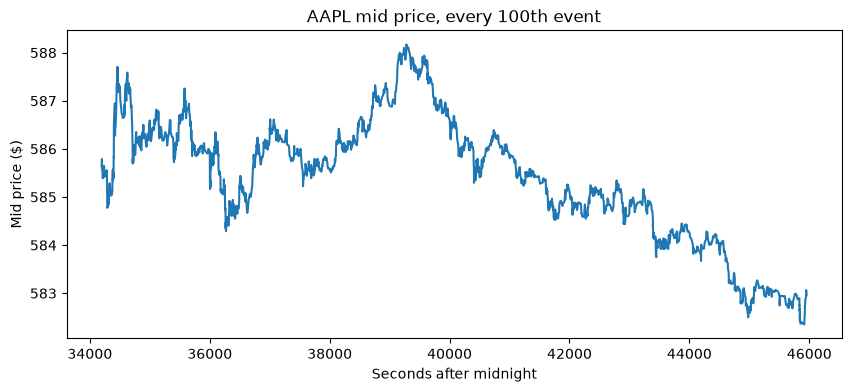

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(features['time_seconds'].iloc[::100], features['mid_price'].iloc[::100])
ax.set_title('AAPL mid price, every 100th event')
ax.set_xlabel('Seconds after midnight')
ax.set_ylabel('Mid price ($)')
plt.show()

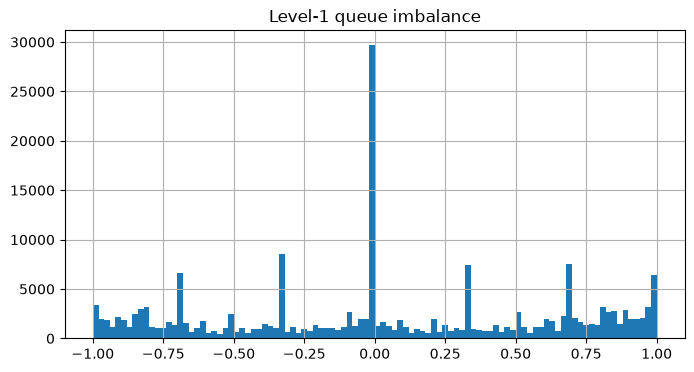

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
features['queue_imbalance_l1'].hist(bins=100, ax=ax)
ax.set_title('Level-1 queue imbalance')
plt.show()

## Record only verified observations

- Rows loaded:
- Timestamp range:
- Event-type distribution:
- Crossed/locked book count:
- Median spread:
- Median inter-arrival time:
- Reconstruction mismatch pattern:
- Suspicious values or data-cleaning decisions: